In [57]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn import ModuleList
import time


device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

# Tokenizer


In [58]:
vocab = set()

with open("Lord of the Rings.txt", "r", encoding="utf-8") as f:
    text = f.read()
    for l in text:
        vocab.add(l)
    vocab = sorted(list(vocab))


print("".join(vocab))
print(len(vocab))


 !"&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]abcdefghijklmnopqrstuvwxyz|}°é—‘’“”
94


In [78]:
# Hyperparameters
max_eval = 10000
batch_size = 64
block_size = 256
learning_rate = 3e-4
vocab_size = len(vocab)
embedding_dim = 384  # = dmodel
feed_forward_dim = 4 * embedding_dim
heads = 6
layers = 6
dropout = 0.2

# Tokenization

In [60]:
string_to_int = { ch:i for i,ch in enumerate(vocab) }
int_to_string = { i:ch for i,ch in enumerate(vocab) }
encode = lambda s: [string_to_int[c] for c in s]
decode = lambda l: ''.join([int_to_string[i] for i in l])

In [61]:
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)

torch.Size([2591430]) torch.int64


# Transformers



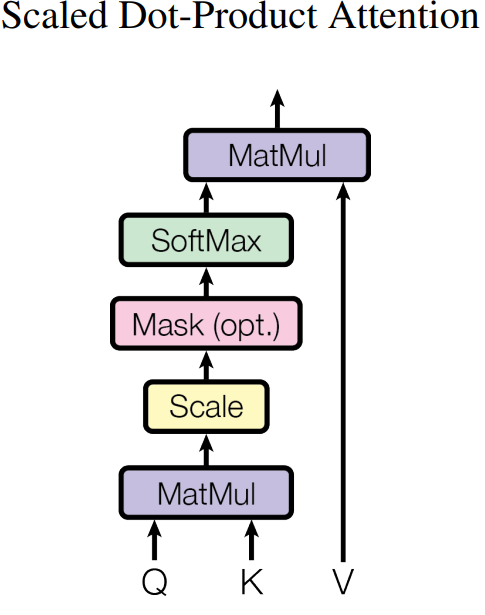

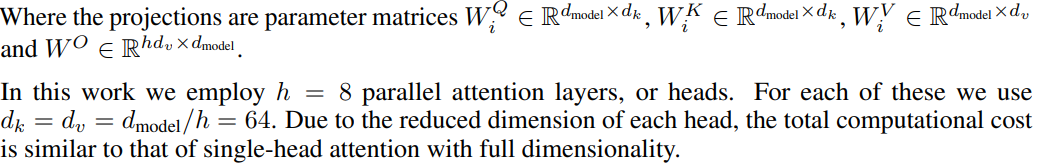









In [62]:
# Implements a single head with the scaled dot product attention
class Head(nn.Module):
    def __init__(self, head_size, mask):
        super().__init__()

        self.Key = nn.Linear(embedding_dim, head_size, bias=False)
        self.Query = nn.Linear(embedding_dim, head_size, bias=False)
        self.Value = nn.Linear(embedding_dim, head_size, bias=False)
        self.mask = mask

        self.dropout = nn.Dropout(dropout)


    def forward(self, x):
        # input size -> Batch, Timestep, Channel
        # output size -> Batch, Timestep, Head size
        B, T, C = x.shape
        K = self.Key(x)    # (B, T, dq)
        Q = self.Query(x)  # (B, T, dq)
        V = self.Value(x)  # (B, T, dv)

        ### Scaled Dot-Product Attention ###
        # Matmult Q x K(transpose) -> Scale -> Softmax -> Matmult result with V
        score_matrix = Q @ K.transpose(-2, -1)     # (B, T, dq) x (B, dq, T) = (B, T, T)
        scaled_score_matrix = score_matrix / (K.shape[-1] ** (-0.5))     # (B, T, T)
        mask = torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()  # upper traingle matrix of ones
        scaled_score_matrix = scaled_score_matrix.masked_fill(mask, float('-inf')) if self.mask else scaled_score_matrix
        softmax_scaled_score_mat = F.softmax(scaled_score_matrix, dim=-1)     # (B, T, T)
        softmax_scaled_score_mat = self.dropout(softmax_scaled_score_mat)
        out = softmax_scaled_score_mat @ V    # (B, T, dv)

        return out



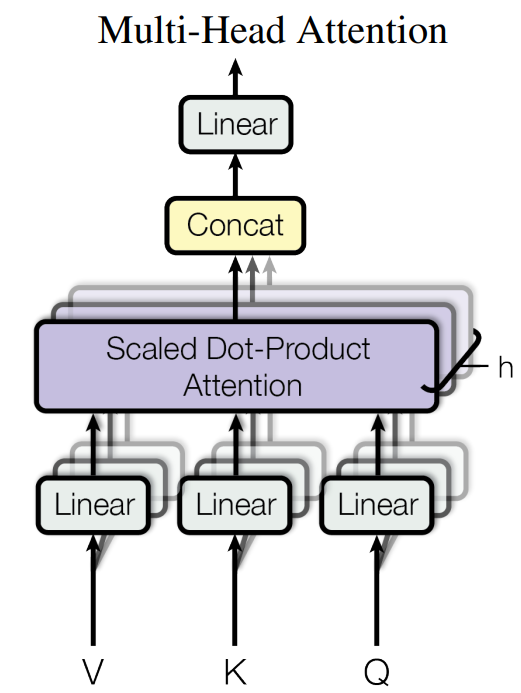

In [63]:
# implements the multi-head attention
class MultiHeadAttention(nn.Module):
    def __init__(self, head_size, mask=False):
        super().__init__()
        self.Heads = ModuleList([Head(head_size, mask) for _ in range(heads)])
        self.WO = nn.Linear(head_size*heads, embedding_dim)

        self.dropout = nn.Dropout(dropout)


    def forward(self, x):
        outs = [head(x) for head in self.Heads]   # heads * (B, T, dv)
        concat = torch.cat(outs, dim=-1)    # (B, T, heads * dv)
        proj = self.WO(concat)    # (B, T, embedding_dim = dmodel)
        out = self.dropout(proj)

        return out




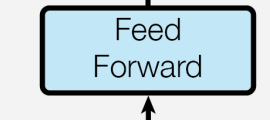

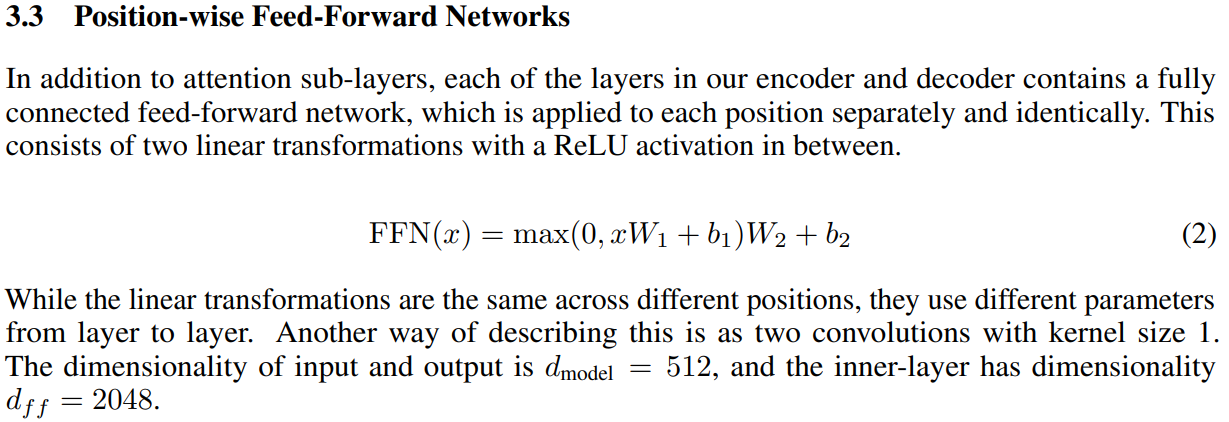

In [64]:
# Implements a position-wise Feed-Forward Network
class FeedForward(nn.Module):
    def __init__(self, dmodel, feed_forward_dim):
        super().__init__()
        self.model= nn.Sequential(
            nn.Linear(dmodel, feed_forward_dim),
            nn.ReLU(),
            nn.Linear(feed_forward_dim, dmodel),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.model(x)




# Encoder

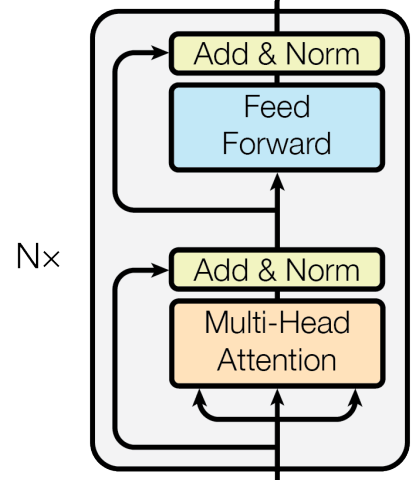

In [65]:
# Implements an entire encoder block
class Encoder(nn.Module):
    def __init__(self, dmodel, feed_forward_dim):  # x = input batch
        super().__init__()
        self.multi_heads = MultiHeadAttention(heads, mask=False)
        self.feed_forward = FeedForward(dmodel, feed_forward_dim)
        self.layer_norm1 = nn.LayerNorm(dmodel)
        self.layer_norm2 = nn.LayerNorm(dmodel)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Multi-Head Attention
        outheads = self.multi_heads(x)
        outheads_dropout = self.dropout(outheads)
        # Add & Norm
        add = x + outheads_dropout
        add_norm = self.layer_norm1(add)
        # Feed Forward
        outff = self.feed_forward(add_norm)
        outff_dropout = self.dropout(outff)
        # Add & Norm
        add = add_norm + outff_dropout
        out = self.layer_norm2(add)

        return out



# Decoder
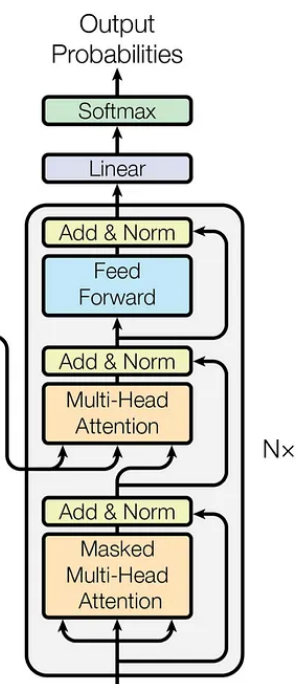

All classes in the decoder's architecture have been implemented, all we have to do is to make a dedicated class to the decoder.

**Note**: Now because I'm building a decoder-only gpt, I'll be skipping the multi-head attention layer that takes inputs from the masked multihead attention layer *AND* the encoder. This is done because we don't need the cross-attention from the encoder. The decoder would look like this: `Masked multihead attention` -> `Add & norm` -> `Feed-Forward` -> `Add & norm` -> `Linear` -> `Softmax`
Thus, the decoder is basically an encoder but instead of using multihead attention, it uses masked multihead attention, so that it would look at the previous sequences and not both previous and future ones.


In [66]:
# Implements a decoder block
class Decoder(nn.Module):
    def __init__(self, dmodel, feed_forward_dim):  # x = input batch
        super().__init__()
        self.multi_heads = MultiHeadAttention(heads, mask=True)  # In this implementation, this single parameter (mask=True) makes this class a decoder.
        self.feed_forward = FeedForward(dmodel, feed_forward_dim)
        self.layer_norm1 = nn.LayerNorm(dmodel)
        self.layer_norm2 = nn.LayerNorm(dmodel)
        self.layer_norm_final = nn.LayerNorm(dmodel)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Multi-Head Attention
        outheads = self.multi_heads(x)
        outheads_dropout = self.dropout(outheads)
        # Add & Norm
        add = x + outheads_dropout
        add_norm = self.layer_norm1(add)
        # Feed Forward
        outff = self.feed_forward(add_norm)
        outff_dropout = self.dropout(outff)
        # Add & Norm
        add = add_norm + outff_dropout
        out = self.layer_norm2(add)

        return out



In [67]:
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

In [68]:
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size, ))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)

    return x, y

# Putting it all together

In [69]:
class mini_GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)
        self.positional_embedding_table = nn.Embedding(block_size, embedding_dim)
        self.transformer_decoder = nn.Sequential(*[Decoder(embedding_dim, feed_forward_dim) for _ in range(layers)])
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B, T) tensors of integers
        token_embeddings = self.token_embedding_table(idx)  # (B, T, C)
        pos_embeddings = self.positional_embedding_table(torch.arange(T, device=device))  # (B, T, C)
        x = token_embeddings + pos_embeddings  # (B, T, C)
        x = self.transformer_decoder(x)
        logits = self.linear(x)


        if targets == None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss


    def generate(self, index, max_new_tokens=500):
        # index is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            index_cond = index[:, -block_size:]
            # get the predictions
            logits, loss = self.forward(index_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            index_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            yield index_next
            # append sampled index to the running sequence
            index = torch.cat((index, index_next), dim=1) # (B, T+1)
        return index


model = mini_GPT()
m = model.to(device)
xb, yb = get_batch("train")
out, loss = m(xb, yb)
print(out, loss)

tensor([[ 0.0972,  0.5257, -0.2088,  ...,  0.0373, -0.7291, -0.2267],
        [-0.0631, -0.2144,  0.4542,  ..., -0.5388,  0.0120,  0.0069],
        [ 0.2853, -0.4680, -0.1341,  ...,  0.5329, -0.3502, -0.8853],
        ...,
        [-0.3421, -1.3290,  0.0897,  ..., -0.3945,  1.0551,  0.6271],
        [-0.9078, -0.2632,  0.1205,  ..., -1.2050,  0.0215,  0.0418],
        [ 0.8307,  0.1272,  0.1740,  ...,  0.5142,  0.0688, -0.0899]],
       grad_fn=<ViewBackward0>) tensor(4.8554, grad_fn=<NllLossBackward0>)


In [ ]:
# Total number of model parameters
total_params = sum(param.numel() for param in m.parameters())
total_params

7607902

In [ ]:
# Create optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=learning_rate)

In [72]:
# state_dict = torch.load('model.pth', weights_only=True)
# model.load_state_dict(state_dict)

In [73]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(100)
        for k in range(100):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [ ]:
for iter in range(max_eval):
    # print(iter)
    if iter % 100 == 0:
        losses = estimate_loss()
        print(f"step: {iter}, train loss: {losses['train']:.3f}, val loss: {losses['val']:.3f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model.forward(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
print(loss.item())

In [ ]:
torch.save(m.state_dict(), "model.pth")

In [ ]:
prompt = 'Who is Gandalf?'
context = torch.tensor(encode(prompt), dtype=torch.long, device=device)
# generated_chars = decode(m.generate(context.unsqueeze(0))[0].tolist())
# An AI generated 'story' 
generated_chars = ''
print("A snippet of a fnunky story from the lord of the rings by mini-GPT.\n\n")
time.sleep(2)


# print('Frodo and Sam went on their journey.\n', end='')

for i in m.generate(context.unsqueeze(0)):
    next_token_id = i[0].item()
    generated_chars = decode([next_token_id])
    print(generated_chars, end='', flush=True)
    time.sleep(0.02)
